In [1]:
import os, re
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

In [2]:
df_endpoint = pd.read_csv('/main/projects/GANomics/plan/SEQC_NB_249_ValidationSamples_ClinicalInfo_20121128.txt',sep="\t",index_col=0)

In [3]:
df_ma_real = pd.read_csv('/main/projects/GANomics/dashboard/backend/results_ms/2_SyncData/NB_50_0/test/microarray_real.csv',index_col=0)
df_ma_fake = pd.read_csv('/main/projects/GANomics/dashboard/backend/results_ms/2_SyncData/NB_50_0/test/microarray_fake.csv',index_col=0)
df_rs_real = pd.read_csv('/main/projects/GANomics/dashboard/backend/results_ms/2_SyncData/NB_50_0/test/rnaseq_real.csv',index_col=0)
df_rs_fake = pd.read_csv('/main/projects/GANomics/dashboard/backend/results_ms/2_SyncData/NB_50_0/test/rnaseq_fake.csv',index_col=0)

In [4]:
# Compute the mean values for comparison
data_means = {
    "Microarray Real": df_ma_real.mean().to_list(),
    "Microarray Syn": df_ma_fake.mean().to_list(),
    "RNAseq Real": df_rs_real.mean().to_list(),
    "RNAseq Syn": df_rs_fake.mean().to_list(),
}

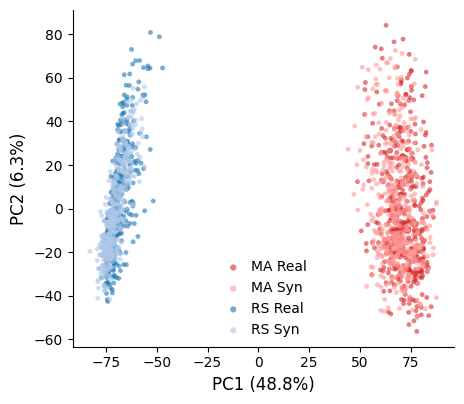

In [22]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

# ---- Global font control ----
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10
})

# Combine all data for PCA
all_data = np.vstack([
    df_ma_real.values,
    df_ma_fake.values,
    df_rs_real.values,
    df_rs_fake.values
])

# Standardize and apply PCA
scaler = StandardScaler()
data_scaled = scaler.fit_transform(all_data)
pca = PCA(n_components=2)
pca_result = pca.fit_transform(data_scaled)

# Labels
n_samples = len(df_ma_real)
labels = np.array(
    ['MA Real'] * n_samples +
    ['MA Syn'] * n_samples +
    ['RS Real'] * n_samples +
    ['RS Syn'] * n_samples
)

# Colors
colors = {
    'MA Real': '#d62728',
    'MA Syn':  '#ff9896',
    'RS Real': '#1f77b4',
    'RS Syn':  '#aec7e8'
}

# ---- Plot ----
fig, ax = plt.subplots(figsize=(4.8, 4.2))

for label, color in colors.items():
    mask = labels == label
    ax.scatter(
        pca_result[mask, 0],
        pca_result[mask, 1],
        color=color,
        label=label,
        alpha=0.6,
        s=12,
        edgecolors='none'
    )

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')

ax.grid(False)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

ax.legend(
    frameon=False,
    loc='best',
    markerscale=1.3,
    handletextpad=0.3,
    borderpad=0.2
)

plt.tight_layout()
plt.show()

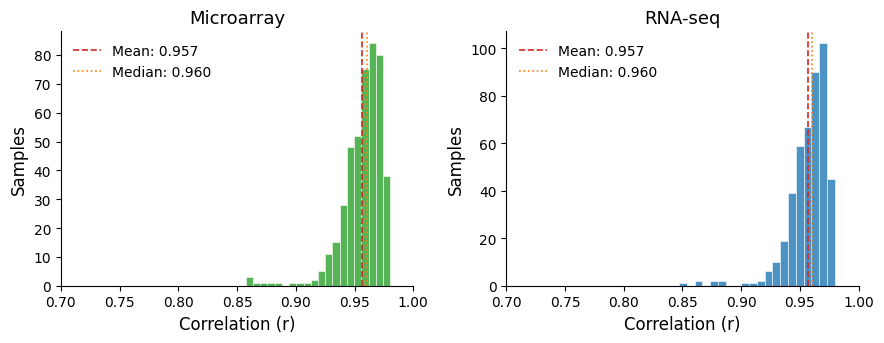

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# ---- Global font control ----
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10
})

# Calculate correlations
sample_correlations_ma = []
sample_correlations_rs = []

for i in range(len(df_ma_real)):
    corr_ma = np.corrcoef(df_ma_real.iloc[i], df_ma_fake.iloc[i])[0, 1]
    corr_rs = np.corrcoef(df_rs_real.iloc[i], df_rs_fake.iloc[i])[0, 1]
    sample_correlations_ma.append(corr_ma)
    sample_correlations_rs.append(corr_rs)

sample_correlations_ma = np.array(sample_correlations_ma)
sample_correlations_rs = np.array(sample_correlations_rs)

# ---- Plot ----
fig, axes = plt.subplots(1, 2, figsize=(9, 3.6))

plot_data = [
    (axes[0], sample_correlations_ma, 'Microarray', '#2ca02c'),
    (axes[1], sample_correlations_rs, 'RNA-seq', '#1f77b4')
]

for ax, values, title, color in plot_data:
    ax.hist(values, bins=20, color=color, alpha=0.8,
            edgecolor='white', linewidth=0.5)

    mean_val = np.mean(values)
    median_val = np.median(values)

    ax.axvline(mean_val, color='#d62728', linestyle='--', linewidth=1.2,
               label=f'Mean: {mean_val:.3f}')
    ax.axvline(median_val, color='#ff7f0e', linestyle=':', linewidth=1.2,
               label=f'Median: {median_val:.3f}')

    ax.set_xlabel('Correlation (r)')
    ax.set_ylabel('Samples')
    ax.set_title(title)

    ax.grid(False)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

    ax.legend(frameon=False, loc='best')
    ax.set_xlim(0.7, 1.0)

plt.tight_layout()
plt.show()

### Individual Samples

In [8]:
# Compute the mean values for comparison
data_means = {
    "Microarray Real": df_ma_real.sample(3).values,
    "Microarray Syn": df_ma_fake.sample(3).values,
    "RNAseq Real": df_rs_real.sample(3).values,
    "RNAseq Syn": df_rs_fake.sample(3).values,
}

In [9]:
# Compute the mean values for comparison
data_means = {
    "Microarray Real": df_ma_real.mean().values,
    "Microarray Syn": df_ma_fake.mean().values,
    "RNAseq Real": df_rs_real.mean().values,
    "RNAseq Syn": df_rs_fake.mean().values,
}

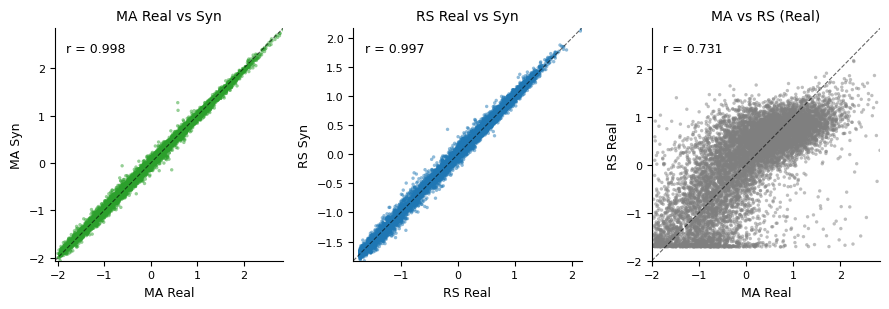

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# ---- Create 1x3 subplot ----
fig, axes = plt.subplots(1, 3, figsize=(9, 3.2))  # compact for panel use

# Softer, consistent colors
colors = ['#2ca02c', '#1f77b4', '#7f7f7f']  # green, blue, gray

# Comparisons
comparisons = [
    ('Microarray Real', 'Microarray Syn', 'MA Real vs Syn'),
    ('RNAseq Real', 'RNAseq Syn', 'RS Real vs Syn'), 
    ('Microarray Real', 'RNAseq Real', 'MA vs RS (Real)')
]

# ---- Plot ----
for idx, (x_data, y_data, title) in enumerate(comparisons):
    ax = axes[idx]

    x = data_means[x_data]
    y = data_means[y_data]

    # Scatter
    ax.scatter(
        x, y,
        s=6,                # small markers
        color=colors[idx],
        alpha=0.5,
        edgecolors='none'
    )

    # Diagonal reference line
    lims = [
        min(np.min(x), np.min(y)),
        max(np.max(x), np.max(y))
    ]
    ax.plot(lims, lims, linestyle='--', color='black', linewidth=0.8, alpha=0.6)

    # Axis limits aligned
    ax.set_xlim(lims)
    ax.set_ylim(lims)

    # Labels (shortened for subplot)
    ax.set_xlabel(x_data.replace('Microarray', 'MA').replace('RNAseq', 'RS'), fontsize=9)
    ax.set_ylabel(y_data.replace('Microarray', 'MA').replace('RNAseq', 'RS'), fontsize=9)

    # Title
    ax.set_title(title, fontsize=10)

    # Correlation annotation (cleaner, no box)
    r = np.corrcoef(x, y)[0, 1]
    ax.text(
        0.05, 0.90,
        f'r = {r:.3f}',
        transform=ax.transAxes,
        fontsize=9
    )

    # Clean style
    ax.grid(False)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

    ax.tick_params(axis='both', labelsize=8)

# Layout
plt.tight_layout()
plt.show()

In [5]:
ind_train = df_endpoint[df_endpoint['SEQC_NB_TrainingValidation']=='SEQC_Training'].index
ind_val = df_endpoint[df_endpoint['SEQC_NB_TrainingValidation']=='SEQC_Validation'].index

NameError: name 'df_endpoint' is not defined

In [14]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef, confusion_matrix

# Function to train KNN and calculate metrics
def train_knn(x_train, y_train, x_test, y_test, k=5):
    # Initialize KNN classifier
    knn = KNeighborsClassifier(n_neighbors=k)

    # Train the model
    knn.fit(x_train, y_train)

    # Make predictions
    y_pred = knn.predict(x_test)

    # Compute metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, pos_label=1)
    recall = recall_score(y_test, y_pred, pos_label=1)  # Sensitivity
    f1 = f1_score(y_test, y_pred)
    mcc = matthews_corrcoef(y_test, y_pred)

    # Compute specificity
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0  # Avoid division by zero

    # Identify misclassified samples
    y_test_np = np.array(y_test)  # Convert to NumPy for easy indexing
    y_pred_np = np.array(y_pred)

    false_positive_indices = np.where((y_test_np == 0) & (y_pred_np == 1))[0]  # FP: Predicted 1 but actual 0
    false_negative_indices = np.where((y_test_np == 1) & (y_pred_np == 0))[0]  # FN: Predicted 0 but actual 1

    misclassified_samples = {
        "FP": false_positive_indices.tolist(),
        "FN": false_negative_indices.tolist()
    }
    
    # Return metrics as a list
    metrics_list = [recall, precision, specificity, f1, mcc, accuracy]

    return metrics_list, misclassified_samples

In [15]:
from sklearn.ensemble import RandomForestClassifier

# Function to train Random Forest and compute metrics
def train_random_forest(x_train, y_train, x_test, y_test, n_estimators=100, random_state=42):
    # Initialize Random Forest classifier
    rf = RandomForestClassifier(n_estimators=n_estimators, random_state=random_state)

    # Train the model
    rf.fit(x_train, y_train)

    # Make predictions
    y_pred = rf.predict(x_test)

    # Compute metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, pos_label=1)
    recall = recall_score(y_test, y_pred, pos_label=1)  # Sensitivity
    f1 = f1_score(y_test, y_pred)
    mcc = matthews_corrcoef(y_test, y_pred)

    # Compute specificity
    # print((y_test, y_pred))
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0  # Avoid division by zero

    # Identify misclassified samples
    y_test_np = np.array(y_test)  # Convert to NumPy for easy indexing
    y_pred_np = np.array(y_pred)

    false_positive_indices = np.where((y_test_np == 0) & (y_pred_np == 1))[0]  # FP: Predicted 1 but actual 0
    false_negative_indices = np.where((y_test_np == 1) & (y_pred_np == 0))[0]  # FN: Predicted 0 but actual 1

    misclassified_samples = {
        "FP": false_positive_indices.tolist(),
        "FN": false_negative_indices.tolist()
    }
    
    # Return metrics as a list
    metrics_list = [recall, precision, specificity, f1, mcc, accuracy]

    return metrics_list, misclassified_samples

In [16]:
def train_model(df_train, df_val, diff=False, mode='KNN', label='D_FAV_All'):
    # Extract labels from df_endpoint
    y_train = df_train['Label'].tolist()
    y_test = df_val['Label'].tolist()
    
    x_train = df_train.drop(['Label'],axis=1).to_numpy()
    x_test = df_val.drop(['Label'],axis=1).to_numpy()
    
    # Train model based on selected mode
    if mode == 'KNN':
        metrics_list, wrong_samples = train_knn(x_train, y_train, x_test, y_test, k=5)
    elif mode == 'RF':
        metrics_list, wrong_samples = train_random_forest(x_train, y_train, x_test, y_test)
    else:
        raise ValueError(f"Unsupported mode: {mode}")

    return metrics_list, wrong_samples

In [59]:
df_ma_real = pd.read_csv('./results/NB_v1/NB_50_ep400_0/Microarray_real.csv',index_col=0)
df_ma_fake = pd.read_csv('./results/NB_v1/NB_50_ep400_0/Microarray_fake.csv',index_col=0)
df_rs_real = pd.read_csv('./results/NB_v1/NB_50_ep400_0/RNAseq_real.csv',index_col=0)
df_rs_fake = pd.read_csv('./results/NB_v1/NB_50_ep400_0/RNAseq_fake.csv',index_col=0)

In [60]:
conf_dict = {
    'C1 - Microarray': [df_ma_real, df_ma_real],
    'C2 - Microarray': [df_ma_real, df_ma_fake],
    'C3 - Microarray': [df_ma_fake, df_ma_real],
    'C4 - Microarray': [df_ma_fake, df_ma_fake],
    'C1 - RNAseq': [df_rs_real, df_rs_real],
    'C2 - RNAseq': [df_rs_real, df_rs_fake],
    'C3 - RNAseq': [df_rs_fake, df_rs_real],
    'C4 - RNAseq': [df_rs_fake, df_rs_fake],    
}
res=[]
for label in ['D_FAV_All', ]: # 'A_EFS_All','B_OS_All', 'C_SEX_All', 
    for k in conf_dict.keys():
        dataset_1 = conf_dict[k][0]
        dataset_1['Label'] = df_endpoint.loc[dataset_1.index, label].values.tolist()
        dataset_1 = dataset_1[dataset_1.index.isin(df_endpoint.dropna(subset=[label]).index)]
        data_train = dataset_1[dataset_1.index.isin(ind_train)]
        
        dataset_2 = conf_dict[k][1]
        dataset_2['Label'] = df_endpoint.loc[dataset_2.index, label].values.tolist()
        dataset_2 = dataset_2[dataset_2.index.isin(df_endpoint.dropna(subset=[label]).index)]
        data_test = dataset_2[dataset_2.index.isin(ind_val)]
        
        
        # print(dataset_1.shape, dataset_2.shape)
        metrics_list, wrong_samples= train_model(data_train, data_test, mode='RF', label=label) # KNN
        res.append([label, k, ]+metrics_list+[wrong_samples['FP'], wrong_samples['FN']])# 
df_res = pd.DataFrame(res, columns =['Endpoint', 'Configuration', 'recall', 'precision', 'specificity', 'f1', 'mcc', 'accuracy', 'FPs', 'FNs']) #, 
df_res

,Endpoint,Configuration,recall,precision,specificity,f1,mcc,accuracy,FPs,FNs
0,D_FAV_All,C1 - Microarray,0.904762,0.863636,0.918919,0.883721,0.815844,0.913793,"[1, 72, 75, 78, 80, 112]","[37, 52, 63, 100]"
1,D_FAV_All,C2 - Microarray,0.857143,0.972973,0.986486,0.911392,0.869917,0.939655,[1],"[24, 25, 37, 52, 63, 100]"
2,D_FAV_All,C3 - Microarray,0.952381,0.754717,0.824324,0.842105,0.749357,0.870690,"[1, 44, 47, 48, 56, 57, 58, 75, 78, 80, 97, 10...","[24, 63]"
3,D_FAV_All,C4 - Microarray,0.904762,0.904762,0.945946,0.904762,0.850708,0.931034,"[1, 41, 78, 112]","[25, 37, 52, 63]"
4,D_FAV_All,C1 - RNAseq,0.857143,0.857143,0.918919,0.857143,0.776062,0.896552,"[1, 72, 75, 78, 80, 112]","[24, 25, 37, 63, 82, 100]"
5,D_FAV_All,C2 - RNAseq,0.857143,0.923077,0.959459,0.888889,0.830756,0.922414,"[1, 72, 75]","[24, 25, 37, 52, 63, 100]"
6,D_FAV_All,C3 - RNAseq,0.952381,0.851064,0.905405,0.898876,0.839743,0.922414,"[57, 72, 75, 79, 80, 93, 108]","[24, 63]"
7,D_FAV_All,C4 - RNAseq,0.976190,0.872340,0.918919,0.921348,0.876280,0.939655,"[1, 72, 75, 78, 79, 80]",[63]


In [61]:
df_res.loc[2, 'FPs']

[1, 44, 47, 48, 56, 57, 58, 75, 78, 80, 97, 108, 112]

### Batched Analysis

In [62]:
res=[]
exp_sets = [
    ('v00', '2', '5000'),
    ('v00', '5', '5000'),
    ('v00', '10', '5000'),
    ('v0', '20', '2000'),
    ('v1', '30', '400'),
    ('v1', '40', '400'),
    ('v1', '50', '400'),
    ('v2', '100', '200'),
    ('v2', '150', '200'),
]
for exp, s_size, ep in exp_sets:
    df_ma_real = pd.read_csv(f'./results/NB_{exp}/NB_{s_size}_ep{ep}_0/Microarray_real.csv',index_col=0)
    df_ma_fake = pd.read_csv(f'./results/NB_{exp}/NB_{s_size}_ep{ep}_0/Microarray_fake.csv',index_col=0)
    df_rs_real = pd.read_csv(f'./results/NB_{exp}/NB_{s_size}_ep{ep}_0/RNAseq_real.csv',index_col=0)
    df_rs_fake = pd.read_csv(f'./results/NB_{exp}/NB_{s_size}_ep{ep}_0/RNAseq_fake.csv',index_col=0)
        
    conf_dict = {
            'C1 - Microarray': [df_ma_real, df_ma_real],
            'C2 - Microarray': [df_ma_real, df_ma_fake],
            'C3 - Microarray': [df_ma_fake, df_ma_real],
            'C4 - Microarray': [df_ma_fake, df_ma_fake],
            'C1 - RNAseq': [df_rs_real, df_rs_real],
            'C2 - RNAseq': [df_rs_real, df_rs_fake],
            'C3 - RNAseq': [df_rs_fake, df_rs_real],
            'C4 - RNAseq': [df_rs_fake, df_rs_fake],    
    }
    for label in ['D_FAV_All', ]: # 'A_EFS_All','B_OS_All', 'C_SEX_All', 
        for k in conf_dict.keys():
            dataset_1 = conf_dict[k][0]
            dataset_1['Label'] = df_endpoint.loc[dataset_1.index, label].values.tolist()
            dataset_1 = dataset_1[dataset_1.index.isin(df_endpoint.dropna(subset=[label]).index)]
            data_train = dataset_1[dataset_1.index.isin(ind_train)]
                
            dataset_2 = conf_dict[k][1]
            dataset_2['Label'] = df_endpoint.loc[dataset_2.index, label].values.tolist()
            dataset_2 = dataset_2[dataset_2.index.isin(df_endpoint.dropna(subset=[label]).index)]
            data_test = dataset_2[dataset_2.index.isin(ind_val)]
                
            # print(dataset_1.shape, dataset_2.shape)
            metrics_list, wrong_samples= train_model(data_train, data_test, mode='KNN', label=label) # KNN
            res.append([s_size, ep, label, k, ]+metrics_list)# +[wrong_samples['FP'], wrong_samples['FN']]
df_res = pd.DataFrame(res, columns =['Training Sample', 'Trained Epochs', 'Endpoint', 'Configuration', 'recall', 'precision', 'specificity', 'f1', 'mcc', 'accuracy']) #, 'FPs', 'FNs'
df_res.to_excel('./results/NB_KNN_all.xlsx', index=None)

/main/projects/GANomics/GANomics/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/main/projects/GANomics/GANomics/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/main/projects/GANomics/GANomics/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/main/p

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec

/tmp/ipykernel_36113/1009930567.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_fig['Config'] = [re.sub('- '+metric, '', x).strip() for x in data_fig['Configuration']]
/tmp/ipykernel_36113/1009930567.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_fig['Config'] = [re.sub('- '+metric, '', x).strip() for x in data_fig['Configuration']]


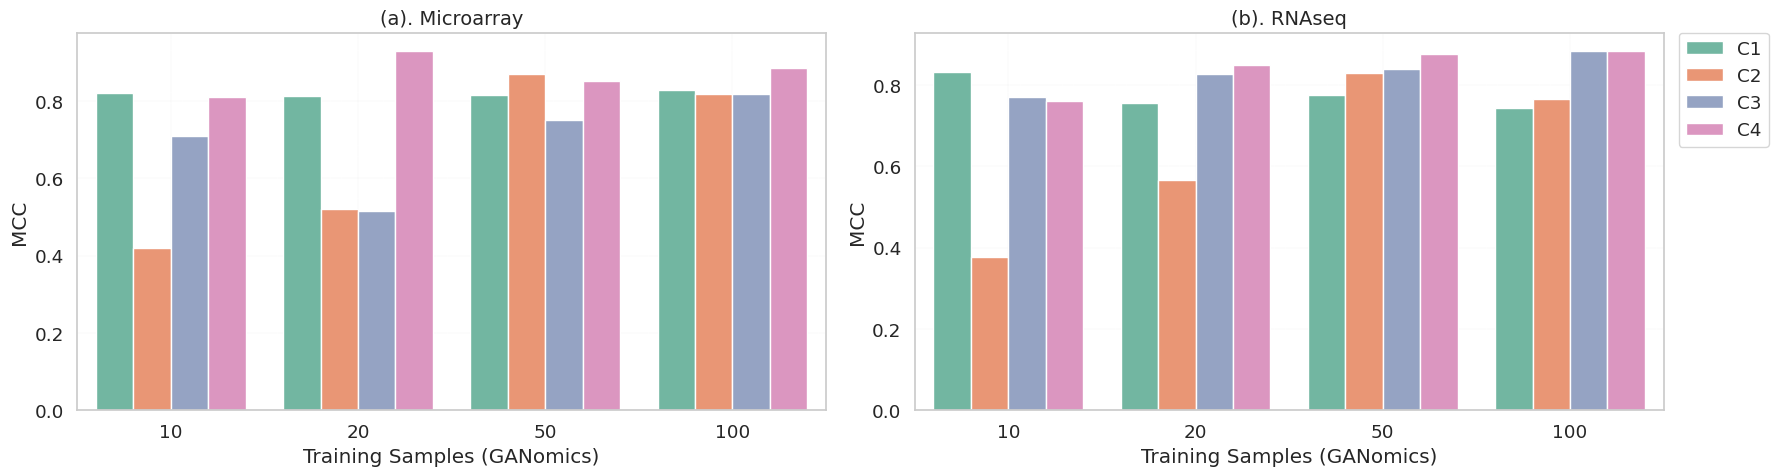

In [77]:
df_res = pd.read_excel('./results/NB_RandomForest_all.xlsx')

# Set style for scientific publication
sns.set_theme(style="whitegrid", font_scale=1.2)
# sns.set_context('talk')
# Create a figure with 2 rows, 4 columns

# Create figure and a 2x4 grid
fig = plt.figure(figsize=(18, 5))
gs = gridspec.GridSpec(1, 2, figure=fig)

# Create subplots
ax1 = fig.add_subplot(gs[0, 0])  # Single plot in row 0, col 0
ax2 = fig.add_subplot(gs[0, 1])  # Single plot in row 0, col 1

# plot series , x-axis = epochs
metrics = ['Microarray', 'RNAseq']
titles = ['(a). Microarray', '(b). RNAseq',]
# Iterate over the first row for loss plots
# df_total_major = df_total# [df_total['train_sample'].isin([100, 150, 200, 250, 300, 350, 400])]
for i, (metric, title) in enumerate(zip(metrics, titles)):
    data_fig = df_res[(df_res['Configuration'].str.contains(metric)) & (df_res['Training Sample'].isin([10, 20, 50, 100]))]
    data_fig['Config'] = [re.sub('- '+metric, '', x).strip() for x in data_fig['Configuration']]
    sns.barplot(data=data_fig, x='Training Sample', y='mcc', hue='Config', ax=eval('ax'+str(i+1)), linewidth=1, palette='Set2', errorbar=None)
    eval('ax'+str(i+1)).set_title(title, fontsize=14)
    eval('ax'+str(i+1)).set_xlabel('Training Samples (GANomics)')
    eval('ax'+str(i+1)).set_ylabel('MCC')
    eval('ax'+str(i+1)).grid(True, linestyle='--', linewidth=0.1)
    if i==1:
        eval('ax'+str(i+1)).legend(loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)
    else:
        eval('ax'+str(i+1)).legend().set_visible(False)
        
# Adjust layout and improve aesthetics
plt.tight_layout()
plt.show()

In [58]:
## Wrong prediction analysis